# Training Deep Neural Networks (Tiếp)
Trong buổi này, chúng ta tiếp tục làm quen với một số kỹ thuật huấn luyện mạng nơ-ron

In [11]:
!nvidia-smi
# from google.colab import drive
# drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import cv2
import torch.nn.functional as F
from torch.autograd import Variable

import torchvision
import torchvision.transforms as transforms

from torch.nn import CrossEntropyLoss, Dropout, Softmax, Linear, Conv2d, LayerNorm
import matplotlib.pyplot as plt
from torchsummary import summary

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


### 1. Cài đặt BatchNorm

In [12]:
def compare_bn(bn1, bn2):
    err = False
    if not torch.allclose(bn1.running_mean, bn2.running_mean):
        print('Diff in running_mean: {} vs {}'.format(
            bn1.running_mean, bn2.running_mean))
        err = True

    if not torch.allclose(bn1.running_var, bn2.running_var):
        print('Diff in running_var: {} vs {}'.format(
            bn1.running_var, bn2.running_var))
        err = True

    if bn1.affine and bn2.affine:
        if not torch.allclose(bn1.weight, bn2.weight):
            print('Diff in weight: {} vs {}'.format(
                bn1.weight, bn2.weight))
            err = True

        if not torch.allclose(bn1.bias, bn2.bias):
            print('Diff in bias: {} vs {}'.format(
                bn1.bias, bn2.bias))
            err = True

    if not err:
        print('All parameters are equal!')


class MyBatchNorm2d(nn.BatchNorm2d):
    def __init__(self, num_features, eps=1e-5, momentum=0.1,
                 affine=True, track_running_stats=True):
        super(MyBatchNorm2d, self).__init__(
            num_features, eps, momentum, affine, track_running_stats)

    def forward(self, input):
        self._check_input_dim(input)

        exponential_average_factor = 0.0

        if self.training and self.track_running_stats:
            if self.num_batches_tracked is not None:
                self.num_batches_tracked += 1
                if self.momentum is None:
                    exponential_average_factor = 1.0 / float(self.num_batches_tracked)
                else:
                    exponential_average_factor = self.momentum

        if self.training:
            mean = input.mean([0, 2, 3])
            var = input.var([0, 2, 3], unbiased=False)
            n = input.numel() / input.size(1)
            with torch.no_grad():
                self.running_mean = exponential_average_factor * mean\
                    + (1 - exponential_average_factor) * self.running_mean
                self.running_var = exponential_average_factor * var * n / (n - 1)\
                    + (1 - exponential_average_factor) * self.running_var
        else:
            mean = self.running_mean
            var = self.running_var

        # Normalize: (x - mean) / sqrt(var + eps)
        input = (input - mean.reshape(1, -1, 1, 1)) / torch.sqrt(var.reshape(1, -1, 1, 1) + self.eps)
        if self.affine:
            # Scale and shift: y = gamma * x_norm + beta
            input = self.weight.reshape(1, -1, 1, 1) * input + self.bias.reshape(1, -1, 1, 1)

        return input


my_bn = MyBatchNorm2d(3, affine=True)
bn = nn.BatchNorm2d(3, affine=True)

compare_bn(my_bn, bn)
my_bn.load_state_dict(bn.state_dict())
compare_bn(my_bn, bn)

for _ in range(10):
    scale = torch.randint(1, 10, (1,)).float()
    bias = torch.randint(-10, 10, (1,)).float()
    x = torch.randn(10, 3, 100, 100) * scale + bias
    out1 = my_bn(x)
    out2 = bn(x)
    compare_bn(my_bn, bn)
    torch.allclose(out1, out2)
    print('Max diff: ', (out1 - out2).abs().max())

my_bn.eval()
bn.eval()
for _ in range(10):
    scale = torch.randint(1, 10, (1,)).float()
    bias = torch.randint(-10, 10, (1,)).float()
    x = torch.randn(10, 3, 100, 100) * scale + bias
    out1 = my_bn(x)
    out2 = bn(x)
    compare_bn(my_bn, bn)
    torch.allclose(out1, out2)


All parameters are equal!
All parameters are equal!
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are

### 2. Cài đặt chiến lược thay đổi tốc độ học: Warm-up + Cosine Annealing LR

In [13]:
def load_data(data_dir="./data"):
    transform = transforms.Compose([
        transforms.ToTensor(),                            
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform)

    testset = torchvision.datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=transform)

    return trainset, testset

class Net(nn.Module):
    def __init__(self, l1=120, l2=84):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.bn1 = nn.BatchNorm2d(6)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2 = nn.BatchNorm2d(16)
        self.fc1 = nn.Linear(16 * 5 * 5, l1)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 16 * 5 * 5)
        x = self.dropout(F.relu(self.fc1(x)))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [14]:
trainset, testset = load_data('./data')
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
)

epochs = 50
warm_epoch = 5
init_lr = 1e-1
last_lr = 1e-5
T_max = epochs
T_cur = 0
lr_list = [0]

net = Net()
device = "cpu"
if torch.cuda.is_available():
    device = "cuda:0"
    if torch.cuda.device_count() > 1:
        net = nn.DataParallel(net)
net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=init_lr, momentum=0.9)

In [15]:
for epoch in range(1, epochs+1):
    running_loss = 0.0
    epoch_steps = 0
    T_cur += 1
    
    # Warm-up: linearly increase LR from 0 to init_lr over warm_epoch epochs
    # Cosine Annealing: decrease LR using cosine function after warm-up
    if epoch <= warm_epoch:
        optimizer.param_groups[0]['lr'] = (1.0 * epoch) / warm_epoch * init_lr
    else:
        optimizer.param_groups[0]['lr'] = last_lr + (init_lr - last_lr) * (1 + np.cos(T_cur * np.pi / T_max)) / 2
   
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_steps += 1
        if i + 1 == len(trainloader):
            print('[Epoch %d] loss: %.3f' % (epoch, running_loss / epoch_steps))
            running_loss = 0.0
            
    lr_list.append(optimizer.param_groups[0]['lr'])

print('Finished Training')


[Epoch 1] loss: 1.721
[Epoch 2] loss: 1.465
[Epoch 3] loss: 1.374
[Epoch 4] loss: 1.332
[Epoch 5] loss: 1.300
[Epoch 6] loss: 1.252
[Epoch 7] loss: 1.224
[Epoch 8] loss: 1.198
[Epoch 9] loss: 1.170
[Epoch 10] loss: 1.152
[Epoch 11] loss: 1.137
[Epoch 12] loss: 1.114
[Epoch 13] loss: 1.103
[Epoch 14] loss: 1.092
[Epoch 15] loss: 1.073
[Epoch 16] loss: 1.059
[Epoch 17] loss: 1.051
[Epoch 18] loss: 1.034
[Epoch 19] loss: 1.023
[Epoch 20] loss: 0.998
[Epoch 21] loss: 0.984
[Epoch 22] loss: 0.975
[Epoch 23] loss: 0.969
[Epoch 24] loss: 0.947
[Epoch 25] loss: 0.934
[Epoch 26] loss: 0.921
[Epoch 27] loss: 0.906
[Epoch 28] loss: 0.895
[Epoch 29] loss: 0.874
[Epoch 30] loss: 0.869
[Epoch 31] loss: 0.851
[Epoch 32] loss: 0.846
[Epoch 33] loss: 0.834
[Epoch 34] loss: 0.824
[Epoch 35] loss: 0.819
[Epoch 36] loss: 0.808
[Epoch 37] loss: 0.795
[Epoch 38] loss: 0.788
[Epoch 39] loss: 0.781
[Epoch 40] loss: 0.777
[Epoch 41] loss: 0.767
[Epoch 42] loss: 0.757
[Epoch 43] loss: 0.757
[Epoch 44] loss: 0.7

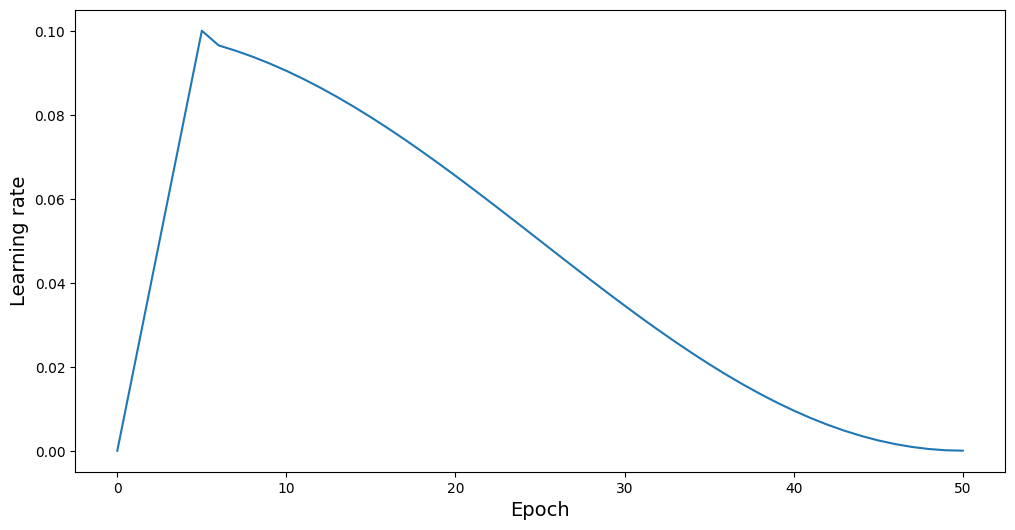

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(list(range(len(lr_list))), lr_list, label="lr")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Learning rate", fontsize=14)
plt.show()

### 3. Tuning siêu tham số

Cài đặt thư viện optuna

In [17]:
!pip install optuna

In [18]:
import optuna
from torch.utils.data import random_split

Viết hàm huấn luyện mô hình nơ-ron trên tập CIFAR10

In [19]:
def train_cifar_optuna(config, data_dir='./data'):
    net = Net(config['l1'], config['l2'])

    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda:0"
        if torch.cuda.device_count() > 1:
            net = nn.DataParallel(net)
    net.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=config["lr"], momentum=0.9)

    trainset, testset = load_data(data_dir)

    test_abs = int(len(trainset) * 0.8)
    train_subset, val_subset = random_split(
        trainset, [test_abs, len(trainset) - test_abs])

    trainloader = torch.utils.data.DataLoader(
        train_subset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
        num_workers=8)
    valloader = torch.utils.data.DataLoader(
        val_subset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
        num_workers=8)

    for epoch in range(5):
        running_loss = 0.0
        epoch_steps = 0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            epoch_steps += 1
            if i % 2000 == 1999:
                print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1,
                                                running_loss / epoch_steps))
                running_loss = 0.0

        val_loss = 0.0
        val_steps = 0
        total = 0
        correct = 0
        for i, data in enumerate(valloader, 0):
            with torch.no_grad():
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = net(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                loss = criterion(outputs, labels)
                val_loss += loss.cpu().numpy()
                val_steps += 1

        print(f"Epoch {epoch+1}: loss={val_loss/val_steps:.4f}, acc={correct/total:.4f}")

    return correct / total

Tuning siêu tham số với Optuna

In [20]:
def objective(trial):
    config = {
        'l1': trial.suggest_categorical('l1', [32, 64]),
        'l2': trial.suggest_categorical('l2', [32, 64]),
        'lr': trial.suggest_categorical('lr', [1e-4, 1e-2]),
        'batch_size': 16,
    }
    accuracy = train_cifar_optuna(config)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f"Best params: {study.best_params}")
print(f"Best accuracy: {study.best_value:.4f}")

[I 2026-04-25 00:13:28,014] A new study created in memory with name: no-name-80714b9e-a911-4c16-8fd3-8bff90bf5eb3


[1,  2000] loss: 1.890
Epoch 1: loss=1.7133, acc=0.3574
[2,  2000] loss: 1.673
Epoch 2: loss=1.6268, acc=0.3997
[3,  2000] loss: 1.592
Epoch 3: loss=1.5718, acc=0.4268
[4,  2000] loss: 1.546
Epoch 4: loss=1.5388, acc=0.4411
[5,  2000] loss: 1.515


[I 2026-04-25 00:26:24,567] Trial 0 finished with value: 0.4537 and parameters: {'l1': 32, 'l2': 32, 'lr': 0.01}. Best is trial 0 with value: 0.4537.


Epoch 5: loss=1.4773, acc=0.4537
[1,  2000] loss: 1.827
Epoch 1: loss=1.6434, acc=0.3962
[2,  2000] loss: 1.583
Epoch 2: loss=1.5429, acc=0.4251
[3,  2000] loss: 1.493
Epoch 3: loss=1.5011, acc=0.4561
[4,  2000] loss: 1.437
Epoch 4: loss=1.4525, acc=0.4804
[5,  2000] loss: 1.403


[I 2026-04-25 00:44:18,248] Trial 1 finished with value: 0.4867 and parameters: {'l1': 64, 'l2': 32, 'lr': 0.01}. Best is trial 1 with value: 0.4867.


...

Epoch 5: loss=1.8405, acc=0.2908
[1,  2000] loss: 2.269
Epoch 1: loss=2.1866, acc=0.1792
[2,  2000] loss: 2.126
Epoch 2: loss=2.0272, acc=0.2126
[3,  2000] loss: 1.991
Epoch 3: loss=1.9556, acc=0.2272
[4,  2000] loss: 1.929
Epoch 4: loss=1.9079, acc=0.2579
[5,  2000] loss: 1.877


[I 2026-04-25 01:55:31,718] Trial 8 finished with value: 0.2749 and parameters: {'l1': 32, 'l2': 64, 'lr': 0.0001}. Best is trial 4 with value: 0.5049.


Epoch 5: loss=1.8521, acc=0.2749
[1,  2000] loss: 1.778
Epoch 1: loss=1.6464, acc=0.3882
[2,  2000] loss: 1.540
Epoch 2: loss=1.5070, acc=0.4533
[3,  2000] loss: 1.463
Epoch 3: loss=1.4805, acc=0.4768
[4,  2000] loss: 1.412
Epoch 4: loss=1.4216, acc=0.4964
[5,  2000] loss: 1.366


[I 2026-04-25 02:04:21,954] Trial 9 finished with value: 0.5166 and parameters: {'l1': 64, 'l2': 64, 'lr': 0.01}. Best is trial 9 with value: 0.5166.


Epoch 5: loss=1.3738, acc=0.5166
Best params: {'l1': 64, 'l2': 64, 'lr': 0.01}
Best accuracy: 0.5166


Cài đặt thử viện skorch

In [21]:
!pip install skorch
import numpy as np
from sklearn.datasets import make_classification
from torch import nn

from skorch import NeuralNetClassifier
from sklearn.model_selection import GridSearchCV

  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)

   ---------------------------------------- 0/2 [tabulate]
   ---------------------------------------- 0/2 [tabulate]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   ------------------

Sử dụng thư viện skorch để huấn luyện

In [22]:
trainset, testset = load_data('./data')
(X, y) = np.asarray(trainset.data[:]), np.asarray(trainset.targets[:])
X = X.reshape((-1, 3, 32, 32))
X = X.astype(np.float32)
y = y.astype(np.int64)

net = NeuralNetClassifier(
    Net,
    max_epochs=5,
    lr=0.01,
    # Shuffle training data on each epoch
    iterator_train__shuffle=True,
)

# training with default config
net.fit(X, y)
y_proba = net.predict_proba(X)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1           nan       0.1025           nan  6.6049
      2           nan       0.1000           nan  5.3402
      3           nan       0.1000           nan  4.2729
      4           nan       0.1000           nan  4.2625
      5           nan       0.1000           nan  4.0075


Dùng skorch để lựa chọn siêu tham số

In [23]:
net.set_params(train_split=False, verbose=0)

# GridSearchCV: exhaustive search over specified hyperparameter values
params = {
    'lr': [0.0001, 0.01],
    'module__l1': [32, 64],
    'module__l2': [16, 32],
}

gs = GridSearchCV(net, params, scoring='accuracy', cv=3, n_jobs=1, verbose=1)
gs.fit(X, y)
print('best score: {:.3f}, best params: {}'.format(gs.best_score_, gs.best_params_))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
best score: 0.106, best params: {'lr': 0.0001, 'module__l1': 64, 'module__l2': 32}
